# Derivatives Credit Risk

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from typing import TypeAlias
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline, interp1d
from dateutil.relativedelta import relativedelta as tdelta

Time: TypeAlias = float
Rate: TypeAlias = float
Date: TypeAlias = pd.Timestamp

In [2]:
mpl.rcParams.update({
    "figure.figsize": (9, 3),
    "figure.dpi": 70,
    "figure.autolayout": True,
    "axes.titlesize": 16,
    "axes.linewidth": 0,
    "axes.facecolor": "#F3F3F3",
    # "text.usetex": True,
    "font.family": "serif",
    "grid.color": "#FFFFFF",
    "axes.grid": True,
})

---

## Business Day Conventions

Before simulating interest rate paths or pricing any swap, we need a reliable way to generate coupon dates and fixing dates that respect market conventions. Raw calendar arithmetic, simply adding 6 months to a date, will often land on weekends or holidays, which is not how real swap schedules work. The BusinessDay class handles this.

### Day Count and Date Shifting Conventions
In fixed income markets, cash flow dates are never left on non-business days. Instead, a business day convention specifies how to roll them:

| Convention | Rule |
| --- | --- |
| Following | Roll to the next business day |
| Preceding | Roll to the previous business day |
| Modified Following | Roll forward, unless doing so crosses into the next calendar month — in that case, roll backward |

Modified Following is by far the most common convention for IRS coupon dates (used in ISDA standard swap schedules), since it keeps cash flows within the same month.

### Tenor Shifting

The `shift(tenor)` method advances a date by a given tenor string (e.g. `"6M"`, `"1Y"`, `"10D"`), applying the appropriate business day adjustment after the shift:

- **Day shifts** (`"D"`) advance one business day at a time, skipping weekends and holidays
- **Week shifts** (`"W"`) add calendar weeks, then apply Following
- **Month and year shifts** (`"M"`, `"Y"`) use calendar month arithmetic, then apply Modified Following — consistent with standard swap schedule generation

This class will be used downstream to build the full **schedule of fixing and payment dates** for our 10Y semi-annual IRS, which in turn defines the simulation time grid $\{t_1, t_2, \ldots, t_{20}\}$ at which we evaluate $\text{MtM}(t)$ distributions.

---

In [3]:
class BusinessDay:
    def __init__(self, date: Date, holidays: list=[]):
        self.date = pd.to_datetime(date)
        self.holidays = holidays

    def is_business_day(self) -> bool:
        return pd.bdate_range(self.date, periods=1, freq="C", holidays=self.holidays)[0] == self.date
    
    def following(self) -> Date:
        if not self.is_business_day():
            self.date = pd.bdate_range(self.date, periods=1, freq="C", holidays=self.holidays)[0]
        return self
        
    def preceding(self) -> Date:
        if not self.is_business_day():
            self.date = pd.bdate_range(end=self.date, periods=1, freq="C", holidays=self.holidays)[0]
        return self
        
    def modified_following(self) -> Date:
        if not self.is_business_day():
            if self.date.month == BusinessDay(self.date).following().date.month:
                self.date = BusinessDay(self.date).following().date
            else:
                self.date = BusinessDay(self.date).preceding().date
        return self
        
    def shift(self, tenor):
        start_date = self.date
        holidays = self.holidays
        shift_amount = float(tenor[:-1])
        shift_type = tenor[-1].upper()

        if tenor == "0D":
            return self
        
        elif shift_type == "D":
            end = start_date
            
            for _ in range(1, int(shift_amount) + 1):
                end = BusinessDay(end + tdelta(days=1), holidays).following().date
            return BusinessDay(end)
        
        elif shift_type == "W":
            return BusinessDay(start_date + tdelta(days=7 * shift_amount), holidays).following()
        
        elif shift_type in ["M", "Y"]:
            delta = {"M": 1, "Y": 12}[shift_type] * shift_amount
            return BusinessDay(start_date + tdelta(months=delta), holidays).modified_following()

---

## Zero Curve Construction and Interpolation

The `ZeroCurve` class takes a discrete set of market-observed zero rates (as provided in the project, with tenors in years) and turns them into a **continuous, differentiable curve**. This is necessary because swap cash flows and Hull-White simulation steps fall on arbitrary dates that will not in general coincide with the quoted tenors.

### Interpolation on Log-Discount Factors

Rather than interpolating directly on zero rates, we interpolate on **log-discount factors**:

$$\ln P(0, t) = -t \cdot Z(0, t)$$

This is the standard market practice — it guarantees that the resulting discount factors are always positive and produces smoother forward curves. We then fit a **natural cubic spline** through the log-discount factor nodes, and recover the discount factor as:

$$P(0, t) = e^{\text{CubicSpline}(t)}$$

### Derived Quantities

From the interpolated discount curve, the class exposes three quantities used throughout the project:

- **Discount factor** $P(0,t)$: used directly in swap pricing and XVA calculations
- **Zero rate** $Z(0,t) = -\frac{\ln P(0,t)}{t}$: used for curve display and validation
- **Instantaneous forward rate** $f(0,t)$: computed via a central finite difference

$$f(0, t) = -\frac{\partial \ln P(0,t)}{\partial t} \approx -\frac{\ln P(0, t+\varepsilon) - \ln P(0, t-\varepsilon)}{2\varepsilon}$$

This last quantity is critical for the Hull-White model, where the $\alpha(t)$ function — which enforces consistency with today's curve — is defined as:

$$\alpha(t) = f(0, t) + \frac{\sigma^2}{2a^2}\left(1 - e^{-at}\right)^2$$

---

In [4]:
# -- Zero Curve --------------------------------------------
class ZeroCurve:
    def __init__(self, tenors: list[Time], rates: list[Rate]):
        self.curve_points = np.array(list(zip(tenors, rates)))
        self.__sort()

    def append(self, curve_point: tuple):
        self.curve_points = np.vstack((self.curve_points, curve_point))
        self.__sort()

    def __sort(self):
        self.curve_points = np.array(sorted(self.curve_points, key=lambda x: x[0]))
        self.tenors = self.curve_points.T[0]
        self.rates = self.curve_points.T[-1]
    
    def interpolator(self):
        # Log Discount Factors
        log_dfs = -self.curve_points.T[0] * self.curve_points.T[1]

        # Cubit Interpolator
        interpolator = CubicSpline(self.tenors, log_dfs, bc_type="natural")

        return lambda t: np.exp(interpolator(t))
    
    def discount(self, t):
        # Get Discount Factor
        interpolator = self.interpolator()
        return interpolator(t)
    
    def zero_rate(self, t):
        # Get Rate
        t = np.where(t == 0, 1e-10, t)
        return -np.log(self.discount(t)) * (1 / t)
    
    def inst_fwd_rate(self, t):
        e = 1e-5
    
        u = np.log(self.discount(t + e))
        d = np.log(self.discount(t - e))

        return -(u - d) / (2 * e)
    
    def time(self, step=1/252):
        # Used for plotting, etc.
        return np.arange(min(self.tenors), max(self.tenors), step=step)

---
## Question 1.
1. Write your own function to simulate the
    * short rate $r(t)$, and
    * the numeraire $e^{-\int_t^T r(s)\,\mathrm{d}s}$
    
    with a Hull-White model.

---

## Hull-White Model Implementation

### Hull-White SDE
$$
\mathrm{d}r(t)=a\big[\theta(t)-r(t)\big]\,\mathrm{d}t+\sigma\,\mathrm{d}W(t)
$$

Where $W(t)$ is a Brownian motion under $\mathbb{Q}$, $a>0$ is the mean-reversion speed, $\sigma>0$ is the volatility and $\theta(t)$ is a time-dependent drift calibrated to the zero curve at $t=0$, fitting any smooth initial yield curve exactly.

### Deterministic shift $\alpha(t)$

Rather than working with $\theta(t)$ directly — which would require computing $\partial f(0,t)/\partial t$ numerically and is prone to instability near $t=0$ — we decompose the short rate as $r(t) = x(t) + \alpha(t)$, where $x(t)$ is a zero-mean OU process and $\alpha(t)$ is the deterministic shift that enforces curve consistency:

$$\alpha(t)=f(0,t)+\frac{\sigma^2}{2a^2}\big(1-e^{-at}\big)^2$$

This sidesteps the noisy numerical derivative entirely, since the simulation only requires $\alpha(t)$ evaluated at the grid points.

### Exact short rate evolution

Because the stochastic integral $\sigma\int_s^t e^{-a(t-u)}\mathrm{d}W(u)$ is Gaussian with known variance, a single step from $s$ to $t$ can be drawn **exactly** — no Euler discretisation needed:

$$
r(t)=\underbrace{r(s)\,e^{-a(t-s)}}_{\text{mean reversion}}+\underbrace{\alpha(t)-\alpha(s)\,e^{-a(t-s)}}_{\text{curve fit}}+\underbrace{\sqrt{\frac{\sigma^2}{2a}\!\left(1-e^{-2a(t-s)}\right)}\cdot Z}_{\text{stochastic}},\quad Z\sim\mathcal{N}(0,1)
$$

### Zero-coupon bond pricing

A key advantage of Hull-White is the **closed-form ZCB price** at any future state $r(t)$:

$$
P(t,T) = A(t,T)\,e^{-B(t,T)\,r(t)}
$$

where the functions $B(t,T)$ and $A(t,T)$ are:

$$
B(t,T)=\frac{1-e^{-a(T-t)}}{a}, \qquad A(t,T)=\frac{P(0,T)}{P(0,t)}\exp\!\left(B(t,T)\,f(0,t)-\frac{\sigma^2}{4a}\left(1-e^{-2at}\right)B(t,T)^2\right)
$$

Note how $A(t,T)$ is anchored to today's discount curve via $P(0,T)/P(0,t)$, which is what guarantees the model replicates the initial zero curve exactly.

### Numeraire accumulation

For path-consistent discounting we accumulate the numeraire $N(t) = e^{-\int_0^t r(s)\,\mathrm{d}s}$ step by step. At each step from $t_i$ to $t_{i+1}$ we use the closed-form ZCB:

$$
N(t_{i+1}) = N(t_i) \cdot P(t_i,\, t_{i+1},\, r(t_i))
$$

This is exact under Hull-White and keeps the numeraire path fully consistent with the simulated short rate, ensuring the martingale condition $P(0,t) = \mathbb{E}^{\mathbb{Q}}[N(t)]$ holds.

In [5]:
# -- Deterministic Component -------------------------------
def alpha(
        curve: ZeroCurve,
        t: Time,
        a: Time,
        sigma: float) -> float:
    
    term_a = curve.inst_fwd_rate(t)
    term_b = sigma ** 2 / (2 * a ** 2)
    term_c = (1 - np.exp(-a * t)) ** 2

    return term_a + term_b * term_c

### Hull-White model implementation

Parameters:
- $a$ = mean-reversion speed
- $\sigma$ = volatility

In [6]:
# -- Hull White --------------------------------------------
class HullWhite:
    def __init__(self, a, sigma, curve):
        self.a     = a
        self.sigma = sigma
        self.curve = curve

    def B(self, t, T):
        a = self.a
        return 1 / a * (1 - np.exp(-a * (T - t)))
    
    def A(self, t, T):
        curve, a, sigma = self.curve, self.a, self.sigma
        B = self.B(t, T)

        term_a = curve.discount(T) / curve.discount(t)
        term_b = B * curve.inst_fwd_rate(t)
        term_c = sigma ** 2 / (4 * a) * (1 - np.exp(-2 * a * t)) * B ** 2
        
        return term_a * np.exp(term_b - term_c)
    
    def ZCB(self, t, T, r_t):
        return self.A(t, T) * np.exp(-self.B(t, T) * r_t)
    
    def simulate(self, time_steps, n_paths=10_000):
        a, sigma, curve = self.a, self.sigma, self.curve

        # Time
        steps = len(time_steps)

        # Initialize
        r = np.zeros((n_paths, steps))
        r[:, 0] = curve.inst_fwd_rate(0)
        num = np.ones_like(r)

        # Random component
        z = np.random.randn(n_paths, steps)

        # Simulation
        for i in range(steps - 1):
            step = time_steps[i + 1] - time_steps[i]
            t = i * step
            t_next = (i + 1) * step

            term_a = r[:, i] * np.exp(-a * step)
            term_b = alpha(curve, t_next, a, sigma) - alpha(curve, t, a, sigma) * np.exp(-a * step)
            term_c = z[:, i + 1] * np.sqrt(sigma ** 2 / (2 * a) * (1 - np.exp(-2 * a * step)))

            r[:, i + 1]   = term_a + term_b + term_c
            num[:, i + 1] = num[: , i] * self.ZCB(t, t_next, r[:, i])

        return r, num

---
## Question 2.
2. Show that your implementation is consistent with the basic assumption that your model replicates today's zero curve, i.e.
    - $P(0,t)=\mathbb{E}^{\mathbb{Q}}\big(e^{-\int_0^T r(s)\,\mathrm{d} s}\big)$

    You can test this using several sample zero curves and various parameters of mean-reversion speed and volatility. One sample zero curve, for instance, could be the following:

| T (y) | 1/12 | 0.5 | 1 | 3 | 5 | 10 |
| --- | :---: | :---: | :---: | :---: | :---: | :---: |
| Zero rate (%) | 0.25 | 0.60 | 0.95 | 1.50 | 2.10 | 2.50 |

---

In [7]:
# -- Used Sample Curves ------------------------------------
sample_curve = ZeroCurve(
    [0, 1 / 12, 0.50, 1, 3, 5, 10],
    [0, 0.0025, 0.006, 0.0095, 0.015, 0.021, 0.025],
)

sample_curve_b = ZeroCurve(
    [0, 1 / 12, 1, 5, 10, 30],
    [0, 0.0028, 0.0061, 0.0097, 0.016, 0.028],
)

In [8]:
# Parameters
a = 0.01
sigma = 0.01
time = sample_curve.time()
step = 1 / 12
steps = np.arange(0, 10 + step, step)
n_paths = 10_000

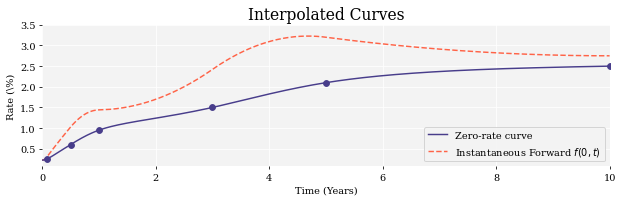

In [9]:
# -- Sample Curve ------------------------------------------
fig, ax = plt.subplots(1, 1)
ax.scatter(sample_curve.tenors[1:], sample_curve.rates[1:], zorder=3, color="darkslateblue")
ax.plot(sample_curve.time(), sample_curve.zero_rate(sample_curve.time()), label="Zero-rate curve", zorder=3, color="darkslateblue")
ax.plot(sample_curve.time(), sample_curve.inst_fwd_rate(sample_curve.time()), label="Instantaneous Forward $f(0,t)$", zorder=2, linestyle="--", color="tomato")
ax.set_ylabel(r"Rate (\%)")
ax.set_xlabel(r"Time (Years)")
ax.set_title("Interpolated Curves")
y_ticks = [i for i in ax.get_yticks() if i != 0]
ax.set_yticks(y_ticks, [rf"{i * 100:.1f}" for i in y_ticks])
ax.set_xlim(0, 10)

plt.legend()
#plt.savefig("Report/figures/CurveInterpolation.pdf", bbox_inches="tight")
plt.show()

In [10]:
# -- Hull-White Model Instance -----------------------------
hw = HullWhite(a, sigma, sample_curve)

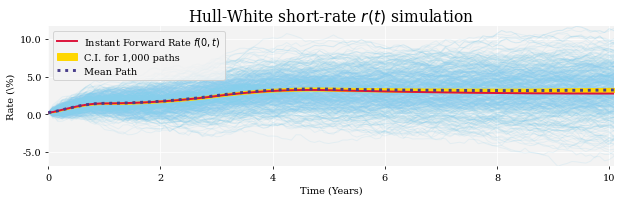

In [11]:
# -- Short-rate Simulation ---------------------------------
paths = hw.simulate(steps, n_paths)[0]
mean_path = paths.mean(axis=0)
mean_std = paths.std(axis=0)
plotted = np.random.choice(range(paths.shape[0]), 500)

fig, ax = plt.subplots(1, 1)

for path in plotted[:-1]:
    ax.plot(steps, paths[path], linewidth=1, color="skyblue", alpha=0.15)

ax.plot(steps, sample_curve.inst_fwd_rate(steps), color="crimson", linewidth=2, label="Instant Forward Rate $f(0,t)$", zorder=5)
ax.fill_between(steps, mean_path - 3 * mean_std / np.sqrt(1000), mean_path + 3 * mean_std / np.sqrt(1000), color="gold", zorder=4, label="C.I. for 1,000 paths")
ax.plot(steps, mean_path, color="darkslateblue", linewidth=3, label="Mean Path", linestyle=":", zorder=6)
y_ticks = [i for i in ax.get_yticks()]
ax.set_yticks(y_ticks, [rf"{i * 100:.1f}" for i in y_ticks])
ax.set_ylabel(r"Rate (\%)")
ax.set_xlabel(r"Time (Years)")
ax.set_title("Hull-White short-rate $r(t)$ simulation")
plt.legend()
plt.margins(0)
# plt.savefig("Report/figures/ShortRate.pdf", bbox_inches="tight")
plt.show()

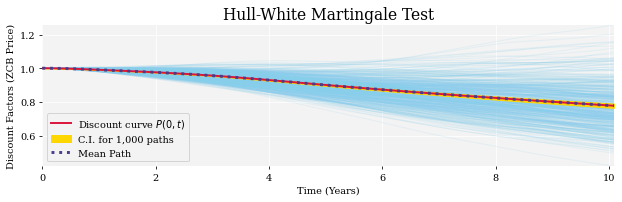

In [12]:
# -- Martingale Validation ---------------------------------
paths = hw.simulate(steps, n_paths)[1]
mean_path = paths.mean(axis=0)
mean_std = paths.std(axis=0)
plotted = np.random.choice(range(paths.shape[0]), 500)

fig, ax = plt.subplots(1, 1)

for path in plotted[:-1]:
    ax.plot(steps, paths[path], linewidth=1, color="skyblue", alpha=0.15)

ax.plot(steps, sample_curve.discount(steps), color="crimson", linewidth=2, label="Discount curve $P(0,t)$", zorder=1001)
ax.fill_between(steps, mean_path - 3 * mean_std / np.sqrt(1000), mean_path + 3 * mean_std / np.sqrt(1000), color="gold", zorder=1000, label="C.I. for 1,000 paths")
ax.plot(steps, mean_path, color="darkslateblue", linewidth=3, label="Mean Path", linestyle=":", zorder=1002)
ax.set_ylabel(r"Discount Factors (ZCB Price)")
ax.set_xlabel(r"Time (Years)")
ax.set_title("Hull-White Martingale Test")
plt.legend()
plt.margins(0)
# plt.savefig("Report/figures/MartingaleTest.pdf", bbox_inches="tight")
plt.show()

### Robustness Check
Alternative parameter combinations $(a,\sigma)\in\left\{(0.005,0.015),(0.005,0.03)\right\}$

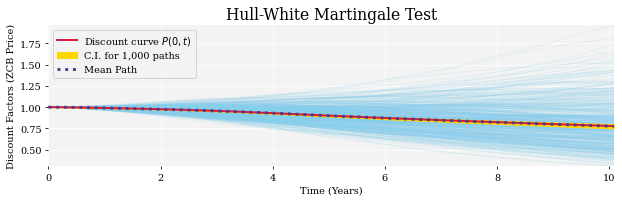

,Value
Test a,0.009147
Test sigma,0.019222


In [13]:
a_shocked = np.random.uniform(5, 15) / 1_000
sigma_shocked = np.random.uniform(0.005, 0.03)

hw_shocked = HullWhite(a_shocked, sigma_shocked, sample_curve)

# -- Martingale Validation ---------------------------------
paths_shocked = hw_shocked.simulate(steps, n_paths)[1]
mean_path_shocked = paths_shocked.mean(axis=0)
mean_std_shocked = paths_shocked.std(axis=0)
plotted = np.random.choice(range(paths_shocked.shape[0]), 500)

fig, ax = plt.subplots(1, 1)

for path in plotted[:-1]:
    ax.plot(steps, paths_shocked[path], linewidth=1, color="skyblue", alpha=0.15)

ax.plot(steps, sample_curve.discount(steps), color="crimson", linewidth=2, label="Discount curve $P(0,t)$", zorder=1001)
ax.fill_between(steps, mean_path_shocked - 3 * mean_std_shocked / np.sqrt(1000), mean_path_shocked + 3 * mean_std_shocked / np.sqrt(1000), color="gold", zorder=1000, label="C.I. for 1,000 paths")
ax.plot(steps, mean_path_shocked, color="darkslateblue", linewidth=3, label="Mean Path", linestyle=":", zorder=1002)
ax.set_ylabel(r"Discount Factors (ZCB Price)")
ax.set_xlabel(r"Time (Years)")
ax.set_title("Hull-White Martingale Test")
plt.legend()
plt.margins(0)
# plt.savefig("Report/figures/ShockedMartingaleTest.pdf", bbox_inches="tight")
plt.show()

pd.DataFrame({
    "Test a": [a_shocked],
    "Test sigma": [sigma_shocked]
    }
).T.rename(columns={0: "Value"})

---
## Question 3.
3. Write your own pricing function for an interest rate swap. Suppose you are under a single curve framework, i.e. your forwarding curve equals the discount curve. With the above zero curve, please ensure that your price of an interest rate swap, with {maturity 10Y, payment frequency every 6 months, K = the fixed rate of the fixed leg = 2.488%}, equals zero - the swap is stroke at par (approximately zero due to potential differences due to the chosen interpolation scheme you use for interpolating between the tenor points of the zero curve to construct the discount and forward curves for each cashflow of your swap).

---

Break-Even Rate  : 2.4822 %
Value @ 2.488%   : -0.00053


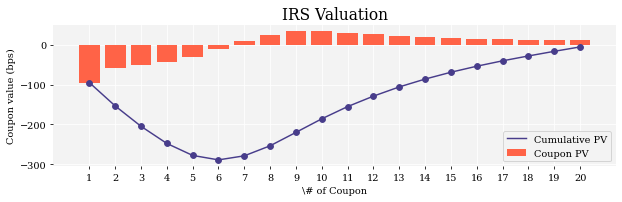

In [14]:
# -- IRS Pricing -------------------------------------------
class IRS:
    def __init__(self,
        value_date: Date,
        trade_date: Date,
        start_date: Date,
        maturity_date: Date,
        frequency: float, # Coupons per year
        notional: float,
        curve: ZeroCurve,
        fixed_rate: float,
        holidays: list=[],
        position: bool=True): # True: pay fix, False: rcv fix
        
        self.value_date = value_date
        self.trade_date = trade_date
        self.start_date = start_date
        self.maturity_date = maturity_date
        self.frequency = frequency
        self.notional = notional
        self.curve = curve
        self.fixed_rate = fixed_rate
        self.holidays = holidays
        self.position = int(position)

    def calendar(self) -> pd.DataFrame:
        start_date, maturity_date, frequency = self.start_date, self.maturity_date, self.frequency
        holidays = self.holidays
        delta = 12 / frequency
        coupon_end = maturity_date
        dates = [coupon_end]
        n = 0
        n_coupons = round((maturity_date - start_date).days / 360, 0) * frequency

        while len(dates) < n_coupons:
            n += 1
            coupon_end = BusinessDay(maturity_date + tdelta(months=-delta * n), holidays).modified_following().date
            dates.append(coupon_end)

        end_date = pd.Series(dates, name="CouponDate").sort_values()
        end_date = end_date[end_date > self.value_date]
        start_date = pd.Series(end_date.shift(1).fillna(max(start_date, self.value_date)), name="FixingDate")

        df = pd.concat([start_date, end_date], axis=1)
        df = df[df.CouponDate > self.value_date]

        df["Notional"] = self.notional
        df["CouponDayFraction"] = df.apply(lambda x: (x.CouponDate - x.FixingDate).days / 360, axis=1)
        df["DiscountFactorStart"] = df.FixingDate.apply(lambda x: self.curve.discount((x - self.trade_date).days / 360))
        df["DiscountFactorEnd"] = df.CouponDate.apply(lambda x: self.curve.discount((x - self.trade_date).days / 360))
        df["ForwardRate"] = (df.DiscountFactorStart / df.DiscountFactorEnd - 1) / df.CouponDayFraction
        return df.sort_values(by=["CouponDate"])

    def fixed_leg(self):
        df = self.calendar()
        df["FixedRate"] = self.fixed_rate
        df["FixedCoupon"] = df.FixedRate * df.Notional * df.CouponDayFraction * (-self.position)
        df["FixedPV"] = df.FixedCoupon * df.DiscountFactorEnd
        return df

    def floating_leg(self):
        df = self.calendar()
        df["FloatingCoupon"] = df.ForwardRate * df.Notional * df.CouponDayFraction * (self.position)
        df["FloatingPV"] = df.DiscountFactorEnd * df.FloatingCoupon
        return df

    def break_even(self):
        floating = self.floating_leg()
        fixed = self.fixed_leg()

        float_pv = (floating.FloatingPV).sum()
        annuity = (fixed.CouponDayFraction * fixed.DiscountFactorEnd * self.notional).sum()
        
        return float_pv / annuity

    def value(self):
        fixed_pv = self.fixed_leg()[["FixingDate", "CouponDate", "CouponDayFraction", "FixedCoupon", "FixedPV"]]
        float_pv = self.floating_leg()[["FloatingCoupon", "FloatingPV"]]
        df = pd.concat([fixed_pv, float_pv], axis=1)
        df["PV"] = df.apply(lambda x: x.FloatingPV + x.FixedPV, axis=1)
        return df.FixedPV.sum(), df.FloatingPV.sum(), df.PV.sum(), df

# Test Parameters
holidays = []
value_date = BusinessDay(pd.Timestamp.now().floor("D")).preceding().date
trade_date = BusinessDay(pd.Timestamp.now().floor("D")).preceding().date
start_date = BusinessDay(trade_date, holidays).shift("2D").date
maturity_date = BusinessDay(start_date, holidays).shift("10Y").date
frequency = 2
notional = 1

test_irs = IRS(value_date, trade_date, start_date, maturity_date, frequency, notional, sample_curve, 0.02488)
break_even = test_irs.break_even()

print(f"Break-Even Rate  : {test_irs.break_even() * 100:.4f} %")
print(f"Value @ 2.488%   : {test_irs.value()[2]:.5f}")

fig, ax = plt.subplots(1, 1)
pv = test_irs.value()[-1].reset_index(drop=True).PV * 10_000
pv_sum = pv.cumsum()
coupons = np.arange(1, 21)
ax.bar([f"{i}" for i in coupons], pv, zorder=3, color="tomato", label="Coupon PV")
ax.plot(coupons-1, pv_sum, zorder=4, color="darkslateblue", label="Cumulative PV")
ax.scatter(coupons-1, pv_sum, zorder=4, color="darkslateblue")
ax.set_ylabel("Coupon value (bps)")
ax.set_xlabel(r"\# of Coupon")
ax.set_title("IRS Valuation")
plt.legend()
# plt.savefig("Report/figures/IRSValuation.pdf", bbox_inches="tight")
plt.show()

---
## Question 4.
Use the functions to simulate short rates under the Hull-White model and to price an interest rate swap to calculate your future $MtM(t)$ distributions for $10,\!000$ scenarios. Your Hull-White model calibration is as follows:
- $\alpha=0.01$,
- $\sigma=0.015$.

Calculate the future $MtM(t)$ distributions for $t$ equal to the union of the fixing and coupon dates of the interest rate swap.

---

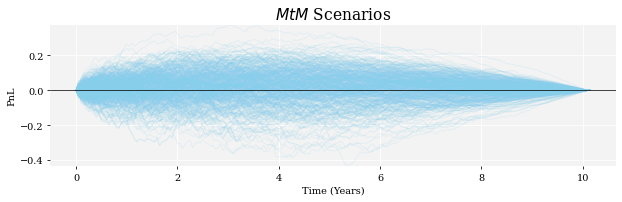

In [15]:
# -- MTM Scenarios -----------------------------------------
# Simulation paths
n_paths = 10_000

# Construct time grid
calendar = test_irs.fixed_leg()
value_dates = np.concat([[value_date], calendar.CouponDate.to_list()])
coupon_times = np.array([(i - value_date).days / 360 for i in value_dates])
time_steps = np.arange(0, coupon_times.max(), 0.05)

# Short rate simulation
hw = HullWhite(a, sigma, sample_curve)
r_paths, numeraire = hw.simulate(time_steps, n_paths)

# MtM
mtm = np.zeros((n_paths, len(time_steps)))

# Loop
for i, date in enumerate(time_steps[1: -1]):
    r_t = r_paths[:, i + 1]
    t = time_steps[i + 1]
    T = time_steps[i + 2:]
    tau = (pd.Series(T) - pd.Series(T).shift(1)).fillna(T[0] - t).to_numpy()
    zcb = np.column_stack([hw.ZCB(t, Ti, r_t) for Ti in T])

    fixed_leg = (zcb * tau * break_even).sum(axis=1)
    floating_leg = (zcb[:, 0] - zcb[:, -1])
    value = (floating_leg - fixed_leg) * notional * test_irs.position

    mtm[:, i + 1] = value

plotted = np.random.choice(range(mtm.shape[0]), 500)

fig, ax = plt.subplots(1, 1)

for path in plotted[:-1]:
    ax.plot(time_steps, mtm[path], linewidth=1, color="skyblue", alpha=0.15)

ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], color="k", linewidth=0.75)
ax.set_ylabel(r"PnL")
ax.set_xlabel(r"Time (Years)")
ax.set_title("$MtM$ Scenarios")
plt.margins(0)
#plt.savefig("Report/figures/MtMScenarios.pdf", bbox_inches="tight")
plt.show()

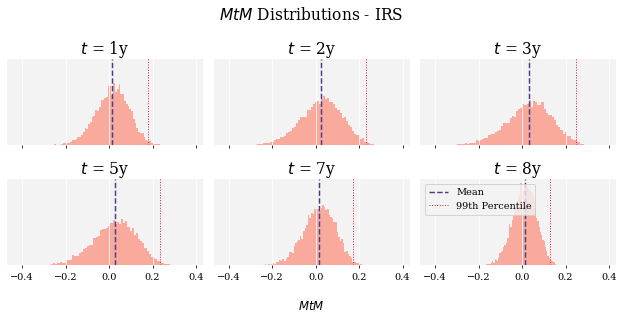

In [16]:
# -- MTM Distribution --------------------------------------
tenors = np.array([1, 2, 3, 5, 7, 8]).reshape(2, -1)

fig, ax = plt.subplots(2, 3, figsize=(9, 4.5), sharex=True, sharey=True)

for i in range(2):
    for j in range(3):
        values = mtm[:, np.where(time_steps == tenors[i, j])[0]]
        ax[i, j].set_title(f"$t$ = {tenors[i, j]}y")
        ax[i, j].hist(values, bins=80, color="tomato", density=True, alpha=0.5)
        ax[i, j].axvline(values.mean(), linewidth=1.5, color="darkslateblue", label="Mean", linestyle="--")
        ax[i, j].axvline(np.percentile(values, 99), linewidth=1, color="crimson", label="99th Percentile", linestyle=":")

plt.suptitle("$MtM$ Distributions - IRS", fontsize=16)
plt.legend()
plt.yticks([])
fig.supxlabel("$MtM$")
# plt.savefig("Report/figures/MtMDistributions.pdf", bbox_inches="tight")
plt.show()

---
## Question 5.

Based on the $MtM(t)$ distributions, calculate the Expected Exposure (EE) ad potential future exposure (PFE, at 99% confidence level) profiles.

---

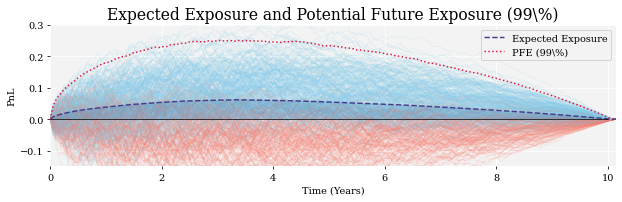

In [17]:
# -- Expected Exposure and PFE -----------------------------
EE = np.maximum(mtm, 0).mean(axis=0)
PFE = np.percentile(mtm, 99, axis=0)

plotted = np.random.choice(range(mtm.shape[0]), 500)

fig, ax = plt.subplots(1, 1)

for path in plotted[:-1]:
    if mtm[path].mean() >= 0:
        ax.plot(time_steps, mtm[path], linewidth=1, color="skyblue", alpha=0.15)
    else:
        ax.plot(time_steps, mtm[path], linewidth=1, color="salmon", alpha=0.15)

ax.fill_between(time_steps, EE, 0, alpha=0.25, zorder=2)
ax.plot(time_steps, EE, color="darkslateblue", label="Expected Exposure", linewidth=1.5, linestyle="--")
ax.plot(time_steps, PFE, color="crimson", label=r"PFE (99\%)", linestyle=":")
ax.hlines(0, 0, 10, color="k", linewidth=0.75)
ax.set_ylabel(r"PnL")
ax.set_xlabel(r"Time (Years)")
ax.set_title(r"Expected Exposure and Potential Future Exposure (99\%)")
plt.legend()
plt.margins(0)
plt.ylim(-0.15, 0.3)
# plt.savefig("Report/figures/EPPFE.pdf", bbox_inches="tight")
plt.show()

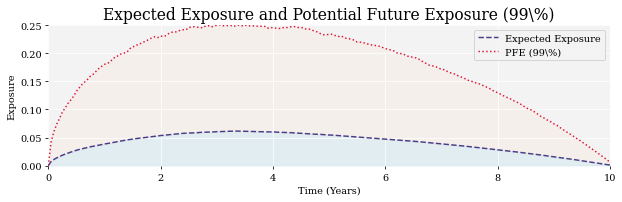

In [18]:
# -- Expected Exposure and PFE -----------------------------
EE = np.maximum(mtm, 0).mean(axis=0)
PFE = np.percentile(mtm, 99, axis=0)

plotted = np.random.choice(range(mtm.shape[0]), 500)

fig, ax = plt.subplots(1, 1)

ax.plot(time_steps, EE, color="darkslateblue", label="Expected Exposure", linewidth=1.5, linestyle="--")
ax.fill_between(time_steps, 0, EE, color="skyblue", alpha=0.15)
ax.plot(time_steps, PFE, color="crimson", label=r"PFE (99\%)", linestyle=":")
ax.fill_between(time_steps, EE, PFE, color="peachpuff", alpha=0.15)
# ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], color="k", linewidth=0.75)
ax.set_ylabel(r"Exposure")
ax.set_xlabel(r"Time (Years)")
ax.set_title(r"Expected Exposure and Potential Future Exposure (99\%)")
ax.set_xlim(0, 10)
plt.legend()
plt.margins(0)
# plt.savefig("Report/figures/EPPFE2.pdf", bbox_inches="tight")
plt.show()

In [19]:
exposure = pd.DataFrame([time_steps, EE, PFE]).T
exposure.columns = ["Time", "EE", "PFE"]
exposure = exposure[exposure.Time.isin(np.arange(0, 10.5, 0.5))].set_index("Time") * 100
exposure

,EE,PFE
Time,,
0.0,0.000000,0.000000
0.5,2.722942,13.237110
1.0,3.847262,18.040281
1.5,4.705440,21.159782
2.0,5.351314,23.057814
2.5,5.801188,24.583940
3.0,6.048438,24.989734
3.5,6.112762,25.066458
4.0,5.989317,24.556505


---
## Question 6.

Calculate the CVA price for the interest rate swap traded with a counterparty with the following credit spread curve:

| T (y) | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| CDS spread (bps) | 53 | 98 | 122 | 132 | 138 | 142 | 144 | 145 | 146 | 147 |

The Loss Given Default (LGD) equals 40%. No collateral is applicable. What is the CVA sensitivity to CDS spread? Calculate the CVA price in the case of the CDS spread curve moves 100bps upwards parallelly.

---

$$
CVA = (1-R_C)\int_0^T\lambda_C(s)P(0,s)\mathrm{EE}(s)\,\mathrm{d}s
$$
where:
* $R_C$ is the recovery rate of the counterparty
* $\lambda_C(t)$ is the hazar rate (intensity) of default, extracted from CDS spreads
* $P(0,s)$ is the risk-free discount factor
* $\mathrm{EE}(s)$ is the expected exposure at time $s$

In [20]:
# -- CDS Spreads -------------------------------------------
cds_tenors = np.arange(1, 11, dtype=float)
cds_spreads = np.array([53, 98, 122, 132, 138, 142, 144, 145, 146, 147]) / 10_000

LGD = 0.4
RR = 1 - LGD

hazard_rates = cds_spreads / LGD

In [21]:
# -- Bootstrap Hazard Rates --------------------------------
def bootstrap_hazard_rates(cds_tenors, cds_spreads, discount_curve, LGD):
    n = len(cds_tenors)
    lambdas = np.zeros(n)
    Q_pillars = np.ones(n + 1)

    pillar_times = np.concatenate([[0.0], cds_tenors])

    for k in range(n):
        T_k = cds_tenors[k]
        s_k = cds_spreads[k]

        # Quarterly payment dates up to T_k
        pay_times = np.arange(0.25, T_k + 1e-8, 0.25)
        tau       = np.full(len(pay_times), 0.25)
        dfs       = discount_curve.discount(pay_times)

        def survival_at(t, lam_k, k=k):
            """Q(t) given lambda_k applies on (T_{k-1}, T_k]."""
            T_prev = pillar_times[k]
            Q_prev = Q_pillars[k]

            if t <= T_prev:
                # Before current interval — use already-fitted survival
                idx = np.searchsorted(pillar_times, t, side='right') - 1
                idx = max(0, min(idx, k))
                if idx == 0:
                    return 1.0
                lam_prev = lambdas[idx - 1]
                return Q_pillars[idx - 1] * np.exp(-lam_prev * (t - pillar_times[idx - 1]))
            else:
                # Within current interval
                return Q_prev * np.exp(-lam_k * (t - T_prev))

        def npv(lam_k):
            Q_t    = np.array([survival_at(t, lam_k) for t in pay_times])
            Q_prev = np.concatenate([[survival_at(pay_times[0] - 0.25, lam_k)], Q_t[:-1]])
            
            Q_prev = np.array([
                survival_at(max(t - 0.25, 0.0), lam_k) for t in pay_times
            ])

            prem = (s_k * tau * dfs * Q_t).sum()
            prot = (LGD * dfs * (Q_prev - Q_t)).sum()
            return prem - prot

        npv_lo = npv(1e-8)
        npv_hi = npv(5.0)

        if npv_lo * npv_hi > 0:
            lambdas[k] = s_k / LGD
        else:
            lambdas[k] = brentq(npv, 1e-8, 5.0, xtol=1e-8)

        # Store Q at this pillar (index k+1 in Q_pillars)
        T_prev       = pillar_times[k]
        Q_prev_val   = Q_pillars[k]
        Q_pillars[k + 1] = Q_prev_val * np.exp(-lambdas[k] * (T_k - T_prev))

    return lambdas, Q_pillars[1:]

lambdas, Q_pillars = bootstrap_hazard_rates(
    cds_tenors, cds_spreads, sample_curve, LGD
)

pd.DataFrame(list(zip(
    [f"{i:.0f}y" for i in cds_tenors],
    [f"{i:.3%}" for i in lambdas],
    [f"{i:.5f}" for i in Q_pillars]
)), columns=["T", "λ", "Q(T)"]).set_index("T")

,λ,Q(T)
T,,
1y,1.323%,0.98686
2y,3.625%,0.95172
3y,4.372%,0.91101
4y,4.146%,0.87402
5y,4.133%,0.83863
6y,4.145%,0.80458
7y,3.965%,0.77330
8y,3.834%,0.74421
9y,3.903%,0.71572


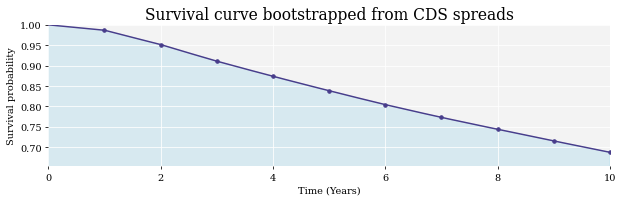

In [22]:
# -- Survival Probability Curve ----------------------------
def survival_probability(t, lambdas=lambdas, tenors=cds_tenors):
    t = np.atleast_1d(np.asarray(t, dtype=float))
    Q = np.zeros_like(t)

    for i, ti in enumerate(t):
        prev = np.concatenate([[0.0], tenors])
        lam_ext = np.concatenate([[lambdas[0]], lambdas])
        H = 0.0
        for n in range(len(tenors)):
            t_start = prev[n]
            t_end = tenors[n]
            if ti <= t_start:
                break
            H += lambdas[n] * (min(ti, t_end) - t_start)
            if ti <= t_end:
                break
        Q[i] = np.exp(-H)

    return Q

# Plot survival curve
t_check = np.linspace(0, 10, 200)
surv = survival_probability(t_check)

fig, ax = plt.subplots(1, 1)
ax.plot(t_check, surv, color="darkslateblue")
ax.scatter(cds_tenors, Q_pillars, color="darkslateblue", zorder=3, s=13)
ax.fill_between(t_check, 0, surv, alpha=0.25, color="skyblue")
ax.set_title("Survival curve bootstrapped from CDS spreads")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Survival probability")
ax.set_ylim(surv.min() * 0.95, 1.0)
plt.margins(0)
# plt.savefig("Report/figures/SurvivalProbability.pdf", bbox_inches="tight")
plt.show()

In [23]:
# -- EE at Coupon Dates ------------------------------------
obs_times = coupon_times[1:]
EE_fine = np.maximum(mtm, 0).mean(axis=0)

# Interpolate EE onto the semi-annual observation dates
EE_interp = interp1d(time_steps, EE_fine, kind='linear', fill_value=0.0, bounds_error=False)
EE_obs = EE_interp(obs_times)

# Discount factors and time intervals at observation dates
dfs_obs = sample_curve.discount(obs_times)
delta_t = np.diff(np.concatenate([[0.0], obs_times]))

# Marginal default probabilities between observation dates
Q_obs = survival_probability(obs_times)
Q_prev = np.concatenate([[1.0], Q_obs[:-1]])
PD_marg = Q_prev - Q_obs

In [24]:
# -- CVA Computation ---------------------------------------
CVA = LGD * np.sum(dfs_obs * EE_obs * PD_marg)

pd.DataFrame([f"{i * 10_000:.4f}" for i in [CVA]], columns=["CVA (bps)"]).T.rename({0: "Value"}, axis=1)

,Value
CVA (bps),48.9174


In [25]:
# -- CVA Sensitivity ---------------------------------------
BUMP = 0.0100 # 100 bps
cds_spreads_b = cds_spreads + BUMP

lambdas_b, Q_pillars_b = bootstrap_hazard_rates(
    cds_tenors, cds_spreads_b, sample_curve, LGD
)

def survival_probability_b(t):
    return survival_probability(t, lambdas_b, cds_tenors)

Q_obs_b = survival_probability_b(obs_times)
Q_prev_b = np.concatenate([[1.0], Q_obs_b[:-1]])
PD_marg_b = Q_prev_b - Q_obs_b

CVA_b = LGD * np.sum(dfs_obs * EE_obs * PD_marg_b)

# Summary table
pd.DataFrame({
    "CVA base (bps)"    : [CVA * 10_000],
    "CVA +100bps (bps)" : [CVA_b * 10_000],
    "ΔCVA (bps)"        : [(CVA_b - CVA) * 10_000],
    "Sensitivity (%)"   : [(CVA_b - CVA) / CVA * 100],
    "LGD (%)"           : [LGD * 100],
    "RR (%)"            : [RR * 100],
}).T.rename(columns={0: "Value"})

,Value
CVA base (bps),48.917363
CVA +100bps (bps),73.985032
ΔCVA (bps),25.067669
Sensitivity (%),51.244930
LGD (%),40.000000
RR (%),60.000000


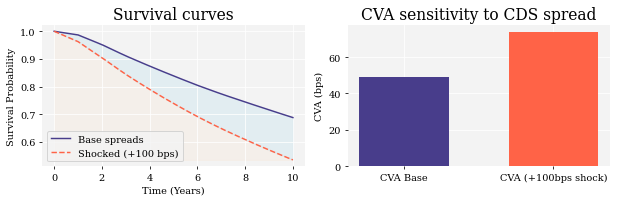

In [26]:
# -- CVA Plot ----------------------------------------------
surv_b = survival_probability_b(t_check)

fig, ax = plt.subplots(1, 2)
ax[0].plot(t_check, surv, label="Base spreads", color="darkslateblue")
ax[0].fill_between(t_check, surv_b.min(), surv_b, color="peachpuff", alpha=0.15)
ax[0].plot(t_check, surv_b, label="Shocked (+100 bps)", color="tomato", linestyle="--")
ax[0].fill_between(t_check, surv, surv_b, color="skyblue", alpha=0.15)
ax[0].legend(loc="lower left")
ax[0].set_title("Survival curves")
ax[0].set_xlabel("Time (Years)")
ax[0].set_ylabel("Survival Probability")

ax[1].bar(["CVA Base", "CVA (+100bps shock)"],
          [CVA * 10_000, CVA_b * 10_000],
          color=["darkslateblue", "tomato"], width=0.6, zorder=3)
ax[1].set_title("CVA sensitivity to CDS spread")
ax[1].set_ylabel("CVA (bps)")
# plt.savefig("Report/figures/CVASens.pdf", bbox_inches="tight")
plt.show()

---
## Question 7.

Calculate the FVA price for this transaction, with $s_F$ - the funding spread on top of risk-free rate - equal to 0.4%.

---

In [27]:
FUNDING_SPREAD = 0.004

FVA = FUNDING_SPREAD * np.sum(dfs_obs * EE_obs * delta_t)

# Summary table
pd.DataFrame({
    "CVA (bps)"          : [CVA * 10_000],
    "FVA (bps)"          : [FVA * 10_000],
    "Total XVA (bps)"    : [(CVA + FVA) * 10_000],
    "Funding spread (%)" : [FUNDING_SPREAD * 100],
}).T.rename(columns={0: "Value"})

,Value
CVA (bps),48.917363
FVA (bps),14.778273
Total XVA (bps),63.695637
Funding spread (%),0.400000


---
## Question 8.

Now suppose that the trade is collateralized, i.e. we (the bank) are asking for collateral (variation margin) our counterparty so to cover/offset the counterparty exposure. Suppose daily margining and immediate collateral transfer. This means that in each of the repricing dates we are fully collateralized and exposed only over the Margin Period of Risk (MPOR). In our example the $\mathrm{MPOR}=10\mathrm{d}$.

(a) Calculate the EE, PFE, CVA and FVA for this collateralized trade.

(b) Comment on what is the impact of collateral to CVA and FVA.

Hint: at day $t_0+30\mathrm{d}$, for instance, we are fully collateralized (i.e. $\mathrm{Collateral}(t_0+30\mathrm{d})^{path=j}=\mathrm{MtM}(t_0+30\mathrm{d})^{path=j}$) and our exposure is from $t_0+30\mathrm{d}$ to $t_0+30\mathrm{d}+\mathrm{MPOR}$. Similarly for all repricing dates.

---

In [28]:
MPOR_DAYS = 10
MPOR = MPOR_DAYS / 360   #in years

collat_times = time_steps[time_steps + MPOR <= time_steps[-1]]

def interpolate_mtm_paths(mtm_matrix, old_grid, new_grid):
    out = np.empty((mtm_matrix.shape[0], len(new_grid)))
    
    for j in range(mtm_matrix.shape[0]):
        out[j, :] = np.interp(new_grid, old_grid, mtm_matrix[j, :])
    
    return out

mtm_t = interpolate_mtm_paths(mtm, time_steps, collat_times)

mtm_t_mpor = interpolate_mtm_paths(mtm, time_steps, collat_times + MPOR)

collateralized_exposure = np.maximum(mtm_t_mpor - mtm_t, 0.0)

EE_collat = collateralized_exposure.mean(axis=0)
PFE_collat = np.percentile(collateralized_exposure, 99, axis=0)

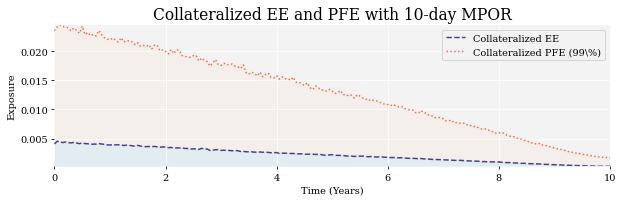

In [29]:
fig, ax = plt.subplots(1, 1)

ax.plot(collat_times, EE_collat, label="Collateralized EE", linewidth=1.5, linestyle="--", color="darkslateblue")
ax.fill_between(collat_times, EE_collat.min(), EE_collat, color="skyblue", alpha=0.15)
ax.plot(collat_times, PFE_collat, label=r"Collateralized PFE (99\%)", linestyle=":", color="tomato")
ax.fill_between(collat_times, PFE_collat, EE_collat, color="peachpuff", alpha=0.15)

ax.set_ylabel("Exposure")
ax.set_xlabel("Time (Years)")
ax.set_title(r"Collateralized EE and PFE with 10-day MPOR")
ax.set_xlim(0, 10)

plt.legend()
plt.margins(0)
# plt.savefig("Report/figures/CollatEE.pdf", bbox_inches="tight")
plt.show()

In [30]:
obs_times_collat = obs_times[obs_times + MPOR <= collat_times[-1]]

EE_collat_interp = interp1d( collat_times, EE_collat, kind="linear", fill_value=0.0, bounds_error=False)

EE_collat_obs = EE_collat_interp(obs_times_collat)

dfs_collat_obs = sample_curve.discount(obs_times_collat)

Q_collat_obs = survival_probability(obs_times_collat)
Q_collat_prev = np.concatenate([[1.0], Q_collat_obs[:-1]])
PD_marg_collat = Q_collat_prev - Q_collat_obs

delta_t_collat = np.diff(np.concatenate([[0.0], obs_times_collat]))

CVA_collat = LGD * np.sum(dfs_collat_obs * EE_collat_obs * PD_marg_collat)
FVA_collat = FUNDING_SPREAD * np.sum(dfs_collat_obs * EE_collat_obs * delta_t_collat)

q8_summary = pd.DataFrame({
    "Uncollateralized CVA (bps)": [CVA * 10_000],
    "Collateralized CVA (bps)": [CVA_collat * 10_000],
    "CVA reduction (bps)": [(CVA - CVA_collat) * 10_000],
    "Uncollateralized FVA (bps)": [FVA * 10_000],
    "Collateralized FVA (bps)": [FVA_collat * 10_000],
    "FVA reduction (bps)": [(FVA - FVA_collat) * 10_000],
    "Max collateralized EE (bps)": [EE_collat.max() * 10_000],
    "Max collateralized PFE (bps)": [PFE_collat.max() * 10_000], }).T.rename(columns={0: "Value"})

q8_summary

,Value
Uncollateralized CVA (bps),48.917363
Collateralized CVA (bps),2.421629
CVA reduction (bps),46.495734
Uncollateralized FVA (bps),14.778273
Collateralized FVA (bps),0.784167
FVA reduction (bps),13.994106
Max collateralized EE (bps),45.507984
Max collateralized PFE (bps),245.496642


In [31]:
q8_exposure_table = pd.DataFrame({ "Time": collat_times, "EE_collateralized": EE_collat, "PFE_99_collateralized": PFE_collat })

q8_exposure_table_report = q8_exposure_table.iloc[ np.linspace(0, len(q8_exposure_table) - 1, 15).astype(int) ].copy()

q8_exposure_table_report[["EE_collateralized", "PFE_99_collateralized"]] *= 10_000
q8_exposure_table_report.rename(columns= {"EE_collateralized": "EE collateralized (bps)", "PFE_99_collateralized": "PFE 99% collateralized (bps)"})

,Time,EE collateralized (bps),PFE 99% collateralized (bps)
0,0.00,40.808155,235.408581
14,0.70,40.530367,228.872189
28,1.40,37.575436,216.336406
43,2.15,33.722509,196.168984
57,2.85,30.227055,179.675914
72,3.60,26.581758,162.255699
86,4.30,24.422789,155.255740
101,5.05,21.496788,127.361889
115,5.75,18.762026,115.264144
129,6.45,16.080852,99.051241


--- 

# Question 9. 

In this question, we extend the previous stochastic interest rate framework to price equity derivative funding costs. We simulate the stock price using a Geometric Brownian Motion, where the drift is given by the stochastic short rate generated by the Hull-White model. We then consider short positions in down-and-in put options with different barrier levels and calculate the corresponding FVA using the same funding spread as before.


---

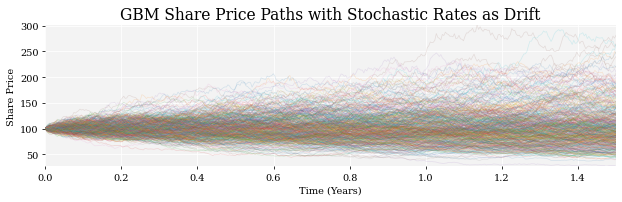

In [32]:
np.random.seed(42)

#Parameters
S0 = 100.0
K = 100.0
T_option = 1.5
sigma_equity = 0.30
position = -1 # short 
barriers = np.array([50, 55, 60, 65, 70, 75, 80], dtype=float)

n_paths_eq = 10_000
dt_eq = 1 / 252
equity_times = np.arange(0, T_option + dt_eq, dt_eq)
n_steps_eq = len(equity_times)

hw_q9 = HullWhite(a, sigma, sample_curve)
r_eq, _ = hw_q9.simulate(equity_times, n_paths_eq)

S_paths = np.zeros((n_paths_eq, n_steps_eq))
S_paths[:, 0] = S0

Z_eq = np.random.randn(n_paths_eq, n_steps_eq - 1)

for i in range(n_steps_eq - 1):
    dt = equity_times[i + 1] - equity_times[i]
    
    S_paths[:, i + 1] = S_paths[:, i] * np.exp( (r_eq[:, i] - 0.5 * sigma_equity ** 2) * dt + sigma_equity * np.sqrt(dt) * Z_eq[:, i] )


discount_to_maturity = np.exp( -np.sum(r_eq[:, :-1] * np.diff(equity_times), axis=1) )

# Plot sample equity paths
plotted = np.random.choice(range(n_paths_eq), 500, replace=False)

fig, ax = plt.subplots(1, 1)

for path in plotted:
    ax.plot(equity_times, S_paths[path], linewidth=0.75, alpha=0.15)

ax.set_title("GBM Share Price Paths with Stochastic Rates as Drift")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Share Price")

plt.margins(0)
# plt.savefig("Report/figures/PricePaths.pdf", bbox_inches="tight")
plt.show()

In [33]:
def regression_basis(S_t, knocked_t, K):
    x = S_t / K
    k = knocked_t.astype(float)
    
    return np.column_stack([ np.ones_like(x), x, x ** 2, x ** 3, k, k * x, k * x ** 2])


def down_and_in_put_lsmc_values(S_paths, r_paths, times, barrier, K):
    n_paths, n_steps = S_paths.shape
    
    running_min = np.minimum.accumulate(S_paths, axis=1)
    knocked = running_min <= barrier
    
    payoff = np.where(knocked[:, -1], np.maximum(K - S_paths[:, -1], 0.0), 0.0)
    
    values = np.zeros_like(S_paths)
    values[:, -1] = payoff
    
    for i in range(n_steps - 2, -1, -1):
        dt = times[i + 1] - times[i]
        
        continuation_disc = values[:, i + 1] * np.exp(-r_paths[:, i] * dt)
        
        if i == 0:
            values[:, i] = continuation_disc.mean()
        
        else:
            X = regression_basis(S_paths[:, i], knocked[:, i], K)
            beta, *_ = np.linalg.lstsq(X, continuation_disc, rcond=None)
            values[:, i] = np.maximum(X @ beta, 0.0)
    
    return values, knocked, payoff

In [34]:
q9_results = []
q9_exposure_profiles = {}

for barrier in barriers:
    
    option_values, knocked, payoff = down_and_in_put_lsmc_values(S_paths=S_paths, r_paths=r_eq, times=equity_times, barrier=barrier, K=K )
    
    option_price_mc = np.mean(discount_to_maturity * payoff)
    
    funding_exposure = np.maximum(-position * option_values, 0.0)
    expected_funding_exposure = funding_exposure.mean(axis=0)
    
    dfs_q9 = sample_curve.discount(equity_times)
    
    FVA_option = FUNDING_SPREAD * np.trapz( dfs_q9 * expected_funding_exposure, equity_times)
    
    knock_in_probability = knocked[:, -1].mean()
    
    q9_results.append({
        "Barrier": barrier,
        "Knock-in probability": knock_in_probability,
        "Long DI put price": option_price_mc,
        "Short-position FVA": FVA_option,
        "FVA bps of S0": FVA_option / S0 * 10_000 })
    
    q9_exposure_profiles[barrier] = expected_funding_exposure

q9_results = pd.DataFrame(q9_results)
q9_results

C:\Users\Startklar\AppData\Local\Temp\ipykernel_22420\2794584909.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  FVA_option = FUNDING_SPREAD * np.trapz( dfs_q9 * expected_funding_exposure, equity_times)


,Barrier,Knock-in probability,Long DI put price,Short-position FVA,FVA bps of S0
0,50.0,0.0727,3.580424,0.029904,2.990375
1,55.0,0.1190,5.333691,0.040852,4.085214
2,60.0,0.1840,7.346668,0.052554,5.255437
3,65.0,0.2616,9.251102,0.062949,6.294873
4,70.0,0.3565,10.895913,0.071579,7.157883
5,75.0,0.4580,12.121626,0.078111,7.811142
6,80.0,0.5681,12.899990,0.083333,8.333349


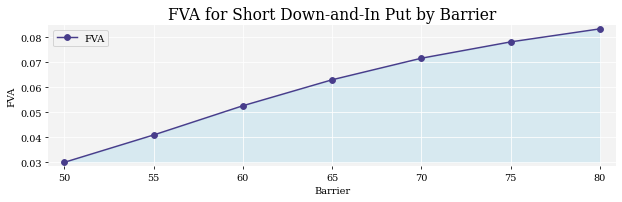

In [35]:
fig, ax = plt.subplots(1, 1)

ax.plot( q9_results["Barrier"], q9_results["Short-position FVA"], marker="o",label="FVA", color="darkslateblue")
ax.fill_between(q9_results["Barrier"], 0.03, q9_results["Short-position FVA"], color="skyblue", alpha=0.25)

ax.set_title("FVA for Short Down-and-In Put by Barrier")
ax.set_xlabel("Barrier")
ax.set_ylabel("FVA")

plt.legend()
plt.margins(0.03)
# plt.savefig("Report/figures/DIPFVA.pdf", bbox_inches="tight")
plt.show()

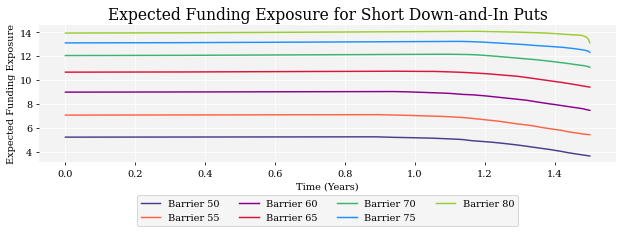

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4))

colors = ["darkslateblue", "tomato", "darkmagenta", "crimson", "mediumseagreen", "dodgerblue", "yellowgreen"]

for i, barrier in enumerate(barriers):
    ax.plot( equity_times, q9_exposure_profiles[barrier], label=f"Barrier {barrier:.0f}", color=colors[i])

ax.set_title("Expected Funding Exposure for Short Down-and-In Puts")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Expected Funding Exposure")

ax.legend(loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.5), fancybox=True)
# plt.savefig("Report/figures/EEDIP.pdf", bbox_inches="tight")
plt.show()